# TOPOLOGICAL DATA SCIENCE TO AUGMENT MACHINE LEARNING AND DEEP LEARNING: A CASE-STUDY OF EPILEPTIC SEIZURE DETECTION


## INITIALIZATION

### Loading Google Drive and Creating Directories

In [1]:
# Loading the google colab package and mounting the google drive to google colab
from google.colab import drive

drive.mount('/content/drive')

# Create the log directory
!mkdir '/content/drive/MyDrive/tda_logs'

# Create the models directory
!mkdir '/content/drive/MyDrive/tda_models'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mkdir: cannot create directory ‘/content/drive/MyDrive/tda_logs’: File exists
mkdir: cannot create directory ‘/content/drive/MyDrive/tda_models’: File exists


#### Installing Pre-requisite Packages

In [2]:
!pip install tensorboardX ray scikeras getml PersistenceImages gudhi persim POT ripser cripser catboost

### Loading Requisite Packages to the Workspace

In [3]:
import random
import joblib
import itertools
import warnings
import glob, os, re
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statistics import mode
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import normalize, to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import BatchNormalization
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input, Dense, Activation, LSTM, GRU, SimpleRNN, Conv1D, TimeDistributed, MaxPooling1D, Flatten, Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.optimizers import Adam, RMSprop

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier





import networkx as nx # For drawing the network diagram of distances
import getml
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from IPython.display import display, clear_output
from PersistenceImages.persistence_images import PersistenceImager


# TDA related libraries
# import cripser
import gudhi
import persim
from gudhi import bottleneck_distance
from gudhi.wasserstein import wasserstein_distance
from ripser import ripser
from persim import PersistenceImager


# Set global variables
%matplotlib inline
pimager = PersistenceImager(pixel_size=0.2)
warnings.filterwarnings("ignore", category=RuntimeWarning)
mpl.rcParams['text.usetex'] = False
getml.engine.launch()

# Hyperparameter tuning
import ray
from ray import train, tune
from ray.tune.schedulers import AsyncHyperBandScheduler
from ray.air.integrations.keras import ReportCheckpointCallback

from tensorflow.keras.optimizers import Adam, RMSprop
from functools import partial
from ray.tune.schedulers import ASHAScheduler





# Setting the random seeds for reproductibility
np.random.seed(42)
random.seed(42)

# Print TDA package persions
# print("cripser:",cripser.__version__)
print("GUDHI:",gudhi.__version__)
print("persim:",persim.__version__)

Launching ./getML --allow-push-notifications=true --allow-remote-ips=false --home-directory=/root/.getML --in-memory=true --install=false --launch-browser=true --log=false --project-directory=/root/.getML/projects in /usr/local/lib/python3.11/dist-packages/getml/.getML/getml-community-1.5.0-amd64-linux...
Launched the getML Engine. The log output will be stored in /root/.getML/logs/getml_20250502220650.log
GUDHI: 3.11.0
persim: 0.3.8


### Importing the Data

In [4]:
# Loading the data
data = pd.read_csv("/content/drive/MyDrive/Epileptic Seizure Recognition.csv")
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


### Utility Functions


#### Functions to apply SMOTE and get features & labels

In [5]:
def apply_smote(X, y, visualize=False):
    """
    Apply SMOTE to balance the dataset and optionally visualize class distributions.
    Args:
        X (np.ndarray or pd.DataFrame): Feature matrix
        y (np.ndarray or pd.Series): Labels
        visualize (bool): If True, plot class distribution before and after SMOTE
    Returns:
        tuple: (X_res, y_res) balanced features and labels
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from imblearn.over_sampling import SMOTE
    import pandas as pd

    if visualize:
        plt.figure(figsize=(6, 3))
        sns.countplot(x=y)
        plt.title('Class Distribution Before SMOTE')
        plt.show()
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X, y)
    if visualize:
        plt.figure(figsize=(6, 3))
        sns.countplot(x=y_res)
        plt.title('Class Distribution After SMOTE')
        plt.show()
    return X_res, y_res

def get_features_and_labels(data, scale=True, balance_data=False, visualize=False):
    """
    Extract features (X) and labels (y) from the dataset.
    Features are columns starting with 'X', label is the 'y' column.
    Optionally scales features and balances data using SMOTE.
    Args:
        data (pd.DataFrame): Input dataframe containing features and labels
        scale (bool): If True, standardize features
        balance_data (bool): If True, apply SMOTE
        visualize (bool): If True, plot class distributions
    Returns:
        tuple: (y, X) where y is labels and X is feature matrix
    """
    y = data['y'] if 'y' in data.columns else data.iloc[:, -1]
    X = data[[x for x in data.columns if x.startswith('X')]] if any(x.startswith('X') for x in data.columns) else data.iloc[:, 1:-1]
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    if balance_data:
        X, y = apply_smote(X, y, visualize=visualize)
    return y, X

#### Function to plot the persistence diagrams

In [6]:
# Function to plot the persistence diagrams
def plot_persistence_diagram(diag, ax=None, id=None):
    # Check if ax is None and create it if necessary
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    persim.plot_diagrams(diag, ax=ax)
    ax.set_title(f'PD of Vietoris-Rips Complex: Subject {id}')
    return plt

#### Function to covert GUDHI to Ripser

In [7]:
# convert GUDHI's diagram to the Ripser style
def gudhi2ripser(diag):
  max_dim = max([p[0] for p in diag])
  return [np.array([p[1:][0] for p in diag if p[0] == i]) for i in range(max_dim+1)]

#### Function to plot the Confusion Matrix and generate the report

In [8]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)

    # Plot the confusion matrix as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()


def generate_classificationReport(y_test, y_pred):
    report = classification_report(y_test, y_pred, zero_division=1)
    return report

#### Functions to train ml models, tune them using Ray Tune and Integrate training and tuning

In [9]:
def train_ml_model_ray(config, constant_params):
    from sklearn.base import clone
    from sklearn.metrics import accuracy_score, f1_score
    X_train = constant_params['X_train']
    y_train = constant_params['y_train']
    X_val = constant_params['X_val']
    y_val = constant_params['y_val']
    model = clone(constant_params['model_class'](**config))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    tune.report({"mean_accuracy":acc, "mean_f1":f1})


def tune_ml_model_ray(model_class, param_space, constant_params, num_samples=10):
    from ray.tune.schedulers import AsyncHyperBandScheduler
    from functools import partial
    scheduler = AsyncHyperBandScheduler(
        metric='mean_accuracy',
        mode='max',
        max_t=20,
        grace_period=1,
        reduction_factor=2,
    )
    result = tune.run(
        partial(train_ml_model_ray, constant_params=constant_params),
        resources_per_trial={'cpu': 1, 'gpu': 0},
        num_samples=num_samples,
        config=param_space,
        scheduler=scheduler,
    )
    print('Best config:', result.get_best_trial('mean_accuracy', 'max', 'last').config)
    return result

def run_ray_tune_benchmark(model_configs, X_train, X_val, y_train, y_val, num_samples=10, results_dir='tda_models'):
    results = []
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)
    for config in model_configs:
        name = config['name']
        model_class = config['model_class']
        param_space = config['param_space']
        print(f"\nRay Tune: Tuning and evaluating: {name}")
        constant_params = {
            'X_train': X_train,
            'y_train': y_train,
            'X_val': X_val,
            'y_val': y_val,
            'model_class': model_class
        }
        try:
            result = tune_ml_model_ray(model_class, param_space, constant_params, num_samples=num_samples)
            best_trial = result.get_best_trial('mean_accuracy', 'max', 'last')
            best_config = best_trial.config
            # Retrain best model on train set and evaluate on val set
            model = model_class(**best_config)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr') if y_proba is not None and len(np.unique(y_val)) > 2 else None
            class_report = generate_classificationReport(y_val, y_pred)
            results.append({
                'Model': name,
                'Best Params': best_config,
                'Val Acc': acc,
                'F1 Score': f1,
                'ROC AUC': roc_auc,
                'Classification Report': class_report
            })
            print(class_report)
            plot_confusion_matrix(y_val, y_pred, classes=np.unique(y_val), title=f"Confusion Matrix: {name}")
        except Exception as e:
            print(f"{name} failed: {e}")
    results_df = pd.DataFrame(results)
    print("\nSummary Table:")
    print(results_df)
    csv_path = os.path.join(results_dir, 'ml_benchmark_ray_results.csv')
    results_df.to_csv(csv_path, index=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y='Val Acc', data=results_df)
    plt.ylabel('Validation Accuracy')
    plt.title('ML Model Benchmark Accuracies (Ray Tuned)')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'ml_benchmark_ray_results.png'))
    plt.show()


#### Specifying ML models and their hyperparameter spaces

In [10]:
# Classical ML Models and their parameter spaces
model_configs = [
    {
        'name': 'LogisticRegression',
        'model_class': LogisticRegression,
        'param_space': {
            'C': tune.choice([0.01, 0.1, 1, 10]),
            'max_iter': tune.choice([500, 1000, 2000]),
            'solver': tune.choice(['lbfgs', 'saga']),
            'class_weight': tune.choice(['balanced', None])
        }
    },
    {
        'name': 'RidgeClassifier',
        'model_class': RidgeClassifier,
        'param_space': {
            'alpha': tune.choice([0.1, 1, 10]),
        }
    },
    {
        'name': 'SGDClassifier',
        'model_class': SGDClassifier,
        'param_space': {
            'loss': tune.choice(['hinge', 'log_loss']),
            'alpha': tune.choice([0.0001, 0.001, 0.01]),
            'max_iter': tune.choice([1000, 2000]),
        }
    },
    {
        'name': 'SVC',
        'model_class': SVC,
        'param_space': {
            'C': tune.choice([0.1, 1, 10]),
            'kernel': tune.choice(['linear', 'rbf']),
            'probability': tune.choice([True]),
        }
    },
    {
        'name': 'KNeighborsClassifier',
        'model_class': KNeighborsClassifier,
        'param_space': {
            'n_neighbors': tune.choice([3, 5, 7, 11]),
            'weights': tune.choice(['uniform', 'distance']),
        }
    },
    {
        'name': 'RandomForestClassifier',
        'model_class': RandomForestClassifier,
        'param_space': {
            'n_estimators': tune.choice([50, 100, 200]),
            'max_depth': tune.choice([None, 5, 10, 20]),
            'min_samples_split': tune.choice([2, 5, 10]),
        }
    },
    {
        'name': 'XGBClassifier',
        'model_class': XGBClassifier,
        'param_space': {
            'n_estimators': tune.choice([50, 100, 200]),
            'max_depth': tune.choice([3, 5, 7]),
            'learning_rate': tune.choice([0.01, 0.1, 0.2]),
            'subsample': tune.choice([0.8, 1.0]),
            'use_label_encoder': tune.choice([False]),
            'eval_metric': tune.choice(['logloss'])
        }
    },
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_space': {
            'n_estimators': tune.choice([50, 100, 200]),
            'max_depth': tune.choice([-1, 5, 10]),
            'learning_rate': tune.choice([0.01, 0.1, 0.2]),
            'subsample': tune.choice([0.8, 1.0]),
        }
    },
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_space': {
            'iterations': tune.choice([100, 200]),
            'depth': tune.choice([4, 6, 10]),
            'learning_rate': tune.choice([0.01, 0.1, 0.2]),
            'verbose': tune.choice([0]),
        }
    },
]

#### Specifying DL models and their hyperparameter spaces

In [11]:
dl_model_configs = [
    {
        'name': 'ANN',
        'model_type': 'ann',
        'param_space': {
            'units': tune.choice([64, 128, 256]),
            'lr': tune.loguniform(1e-4, 1e-2),
            'optimizer': tune.choice(['adam', 'rmsprop', 'sgd']),
            'batch_size': tune.choice([16, 32, 64]),
            'epochs': 30
        }
    },
    {
        'name': 'CNN',
        'model_type': 'cnn',
        'param_space': {
            'filters': tune.choice([16, 32, 64]),
            'lr': tune.loguniform(1e-4, 1e-2),
            'optimizer': tune.choice(['adam', 'rmsprop', 'sgd']),
            'batch_size': tune.choice([16, 32, 64]),
            'epochs': 30
        }
    },
    {
        'name': 'LSTM',
        'model_type': 'lstm',
        'param_space': {
            'units': tune.choice([32, 64, 128]),
            'lr': tune.loguniform(1e-4, 1e-2),
            'optimizer': tune.choice(['adam', 'rmsprop', 'sgd']),
            'batch_size': tune.choice([16, 32, 64]),
            'epochs': 30
        }
    },
    {
        'name': 'GRU',
        'model_type': 'gru',
        'param_space': {
            'units': tune.choice([32, 64, 128]),
            'lr': tune.loguniform(1e-4, 1e-2),
            'optimizer': tune.choice(['adam', 'rmsprop', 'sgd']),
            'batch_size': tune.choice([16, 32, 64]),
            'epochs': 30,
            'momentum': tune.choice([0.0, 0.5, 0.9])
        }
    },
]

#### Functions to build DL models

In [12]:
def build_ann_model(num_classes, input_shape, units=128, learning_rate=0.001, optimizer='adam'):
    model = Sequential()
    model.add(layers.Flatten(input_shape=input_shape))
    model.add(layers.Dense(units, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(units//2, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='sigmoid' if num_classes == 1 else 'softmax'))
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy' if num_classes == 1 else 'categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

def build_cnn_model(num_classes, input_shape, filters=32, learning_rate=0.001, optimizer='adam'):
    model = Sequential()
    model.add(layers.Conv1D(filters, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(layers.Conv1D(filters*2, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='sigmoid' if num_classes == 1 else 'softmax'))
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy' if num_classes == 1 else 'categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

def build_lstm_model(num_classes, input_shape, units=70, learning_rate=0.0001, optimizer='adam'):
    model = Sequential()
    model.add(layers.LSTM(units, return_sequences=True, activation='relu', input_shape=input_shape))
    model.add(layers.LSTM(units, return_sequences=True, activation='relu'))
    model.add(layers.LSTM(units, return_sequences=False, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='sigmoid' if num_classes == 1 else 'softmax'))
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy' if num_classes == 1 else 'categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

def build_gru_model(num_classes, input_shape, units=70, learning_rate=0.0001, momentum=0.95, optimizer='adam'):
    model = Sequential()
    model.add(layers.GRU(units, return_sequences=True, activation='relu', input_shape=input_shape))
    model.add(layers.GRU(units, return_sequences=True, activation='relu'))
    model.add(layers.GRU(units, return_sequences=True, activation='relu'))
    model.add(layers.GRU(units, return_sequences=False, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(Dense(num_classes, activation='sigmoid' if num_classes == 1 else 'softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate, momentum=momentum)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(loss='binary_crossentropy' if num_classes == 1 else 'categorical_crossentropy',
                  optimizer=opt, metrics=['accuracy'])
    print('Model compiled!')
    print(model.summary())
    return model

#### Functions to train and tune DL models

In [13]:
def train_dl_model(config, constant_params, model_type):
    X_train = constant_params['X_train']
    y_train = constant_params['y_train']
    input_shape = X_train.shape[1:]
    num_classes = constant_params['num_classes']

    # Select the model builder based on model_type string
    if model_type == 'ann':
        model = build_ann_model(num_classes, input_shape, units=config['units'], learning_rate=config['lr'], optimizer=config['optimizer'])
    elif model_type == 'cnn':
        model = build_cnn_model(num_classes, input_shape, filters=config['filters'], learning_rate=config['lr'], optimizer=config['optimizer'])
    elif model_type == 'lstm':
        model = build_lstm_model(num_classes, input_shape, units=config['units'], learning_rate=config['lr'], optimizer=config['optimizer'])
    elif model_type == 'gru':
        model = build_gru_model(num_classes, input_shape, units=config['units'], learning_rate=config['lr'], optimizer=config['optimizer'], momentum=config.get('momentum', 0.0))
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.fit(
        X_train, y_train,
        batch_size=config['batch_size'],
        epochs=config['epochs'],
        verbose=0,
        callbacks=[ReportCheckpointCallback(metrics={'mean_accuracy': 'accuracy'})]
    )

def tune_dl_model(model_type, param_space, constant_params):
    from ray.tune.schedulers import AsyncHyperBandScheduler
    from functools import partial
    scheduler = AsyncHyperBandScheduler(
        metric='mean_accuracy',
        mode='max',
        max_t=200,
        grace_period=1,
        reduction_factor=2,
    )
    result = tune.run(
        partial(train_dl_model, constant_params=constant_params, model_type=model_type),
        resources_per_trial={'cpu': 1, 'gpu': 0},
        num_samples=constant_params['num_samples'],
        config=param_space,
        scheduler=scheduler,
    )
    print('Best model is:', result.get_best_trial('mean_accuracy', 'max', 'last').config)
    return result

  def run_ray_tune_dl_benchmark(dl_model_configs, X_train, X_val, y_train, y_val, num_samples=10, results_dir='tda_dl_models', classes=None):
      results = []
      if not os.path.exists(results_dir):
          os.makedirs(results_dir)
      for config in dl_model_configs:
          name = config['name']
          model_type = config['model_type']
          param_space = config['param_space']
          print(f"\nRay Tune: Tuning and evaluating: {name}")
          constant_params = {
              'X_train': X_train,
              'y_train': y_train,
              'X_val': X_val,
              'y_val': y_val,
              'num_classes': len(np.unique(y_train)),
              'num_samples': num_samples
          }
          try:
              result = tune_dl_model(model_type, param_space, constant_params)
              best_trial = result.get_best_trial('mean_accuracy', 'max', 'last')
              best_config = best_trial.config
              input_shape = X_train.shape[1:]
              num_classes = len(np.unique(y_train))
              # Build best model
              if model_type == 'ann':
                  model = build_ann_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
              elif model_type == 'cnn':
                  model = build_cnn_model(num_classes, input_shape, filters=best_config['filters'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
              elif model_type == 'lstm':
                  model = build_lstm_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
              elif model_type == 'gru':
                  model = build_gru_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'], momentum=best_config.get('momentum', 0.0))
              else:
                  raise ValueError(f"Unknown model_type: {model_type}")
              model.fit(X_train, y_train, batch_size=best_config['batch_size'], epochs=best_config['epochs'], verbose=0)
              y_pred = model.predict(X_val)
              if num_classes == 1:
                  y_pred_labels = (y_pred > 0.5).astype(int).flatten()
              else:
                  y_pred_labels = y_pred.argmax(axis=1)
              acc = accuracy_score(y_val, y_pred_labels)
              f1 = f1_score(y_val, y_pred_labels, average='weighted')
              # ROC AUC for binary or multiclass
              if num_classes > 2:
                  y_proba = y_pred if num_classes > 2 else y_pred.flatten()
                  roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr')
              else:
                  y_proba = y_pred.flatten() if num_classes == 2 else y_pred
                  roc_auc = roc_auc_score(y_val, y_proba) if num_classes == 2 else None
              class_report = generate_classificationReport(y_val, y_pred_labels)
              results.append({
                  'Model': name,
                  'Best Params': best_config,
                  'Val Acc': acc,
                  'F1 Score': f1,
                  'ROC AUC': roc_auc,
                  'Classification Report': class_report
              })
              print(class_report)
              plot_confusion_matrix(y_val, y_pred_labels, classes=classes or np.unique(y_val), title=f"Confusion Matrix: {name}")
          except Exception as e:
              print(f"{name} failed: {e}")
      results_df = pd.DataFrame(results)
      print("\nSummary Table:")
      print(results_df)
      csv_path = os.path.join(results_dir, 'dl_benchmark_ray_results.csv')
      results_df.to_csv(csv_path, index=False)
      plt.figure(figsize=(12, 6))
      sns.barplot(x='Model', y='Val Acc', data=results_df)
      plt.ylabel('Validation Accuracy')
      plt.title('DL Model Benchmark Accuracies (Ray Tuned)')
      plt.ylim(0, 1)
      plt.tight_layout()
      plt.savefig(os.path.join(results_dir, 'dl_benchmark_ray_results.png'))
      plt.show()

#### Function to evaluate a tuned DL model

In [14]:
def evaluate_dl_tune_result(result, X_val, y_val, classes, model_type, title_prefix=None):
    # Get best config and retrain best model on train+val, then evaluate on val
    best_config = result.get_best_trial('mean_accuracy', 'max', 'last').config
    # Assume constant_params used for training
    # You may want to pass in the constant_params used, or ensure it is available
    input_shape = X_val.shape[1:]
    num_classes = len(set(y_val)) if hasattr(y_val, '__len__') else 1
    # Pick the right model builder
    if model_type == 'ann':
        model = build_ann_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
    elif model_type == 'cnn':
        model = build_cnn_model(num_classes, input_shape, filters=best_config['filters'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
    elif model_type == 'lstm':
        model = build_lstm_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'])
    elif model_type == 'gru':
        model = build_gru_model(num_classes, input_shape, units=best_config['units'], learning_rate=best_config['lr'], optimizer=best_config['optimizer'], momentum=best_config.get('momentum', 0.0))
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # Fit best model on the full training set (X_val here is just for demonstration; use X_train+X_val ideally)
    # For demo, use X_val/y_val as validation
    model.fit(X_val, y_val, batch_size=best_config['batch_size'], epochs=best_config['epochs'], verbose=0)
    y_pred = model.predict(X_val)
    if num_classes == 1:
        y_pred_labels = (y_pred > 0.5).astype(int).flatten()
    else:
        y_pred_labels = y_pred.argmax(axis=1)
    # Plot confusion matrix
    plot_confusion_matrix(y_val, y_pred_labels, classes, title=(title_prefix or model_type) + ' Confusion Matrix')
    # Print classification report
    print(generate_classificationReport(y_val, y_pred_labels))

## Creating Features and Labels from the data (no TDA)

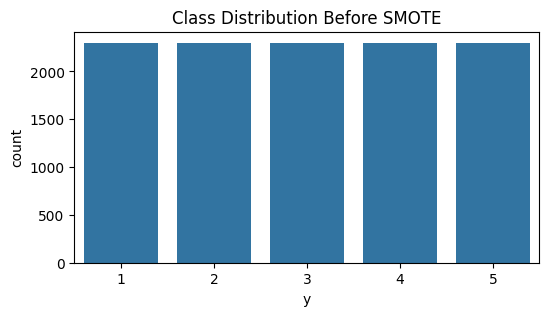

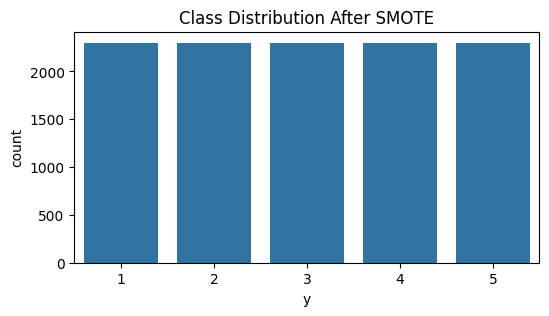

In [15]:
y, X = get_features_and_labels(data, scale=True, balance_data=True, visualize=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training and Tuning Classfication ML models

In [16]:
run_ray_tune_benchmark(model_configs, X_train, X_test, y_train, y_test, num_samples=10)


Ray Tune: Tuning and evaluating: LogisticRegression


2025-05-02 22:06:56,483	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-02 22:06:58,606	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.


+---------------------------------------------------------------------------+
| Configuration for experiment     train_ml_model_ray_2025-05-02_22-06-58   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        AsyncHyperBandScheduler                  |
| Number of trials                 10                                       |
+---------------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_ml_model_ray_2025-05-02_22-06-58
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2025-05-02_22-06-53_578467_1314/artifacts/2025-05-02_22-06-58/train_ml_model_ray_2025-05-02_22-06-58/driver_artifacts`

Trial status: 10 PENDING
Current time: 2025-05-02 22:07:02. Total running time: 3s
Logical resource usage: 0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+---

(func pid=2157) /usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
(func pid=2157)   warnings.warn(



Trial train_ml_model_ray_c4806_00004 started with configuration:
+------------------------------------------------------+
| Trial train_ml_model_ray_c4806_00004 config          |
+------------------------------------------------------+
| C                                                0.1 |
| class_weight                                         |
| max_iter                                        1000 |
| solver                                          saga |
+------------------------------------------------------+

Trial status: 3 TERMINATED | 2 RUNNING | 5 PENDING
Current time: 2025-05-02 22:08:32. Total running time: 1min 33s
Logical resource usage: 2.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name                       status           C     max_iter   solver     class_weight          acc     iter     total time (s)     m

...

LGBMClassifier failed: name 'f1_score' is not defined

Ray Tune: Tuning and evaluating: CatBoostClassifier
+---------------------------------------------------------------------------+
| Configuration for experiment     train_ml_model_ray_2025-05-02_23-27-53   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        AsyncHyperBandScheduler                  |
| Number of trials                 10                                       |
+---------------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_ml_model_ray_2025-05-02_23-27-53
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2025-05-02_22-06-53_578467_1314/artifacts/2025-05-02_23-27-53/train_ml_model_ray_2025-05-02_23-27-53/driver_artifacts`

Trial status: 10 PENDING
Current time: 2025-05-02 23:

2025-05-02 23:49:13,782	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_ml_model_ray_2025-05-02_23-27-53' in 0.0086s.



Trial train_ml_model_ray_11f5e_00004 finished iteration 1 at 2025-05-02 23:49:13. Total running time: 21min 20s
+---------------------------------------------------------+
| Trial train_ml_model_ray_11f5e_00004 result             |
+---------------------------------------------------------+
| checkpoint_dir_name                                     |
| time_this_iter_s                                704.694 |
| time_total_s                                    704.694 |
| training_iteration                                    1 |
| mean_accuracy                                   0.56522 |
| mean_f1                                         0.53765 |
+---------------------------------------------------------+

Trial train_ml_model_ray_11f5e_00004 completed after 1 iterations at 2025-05-02 23:49:13. Total running time: 21min 20s

Trial status: 10 TERMINATED
Current time: 2025-05-02 23:49:13. Total running time: 21min 20s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T

ValueError: Could not interpret value `Model` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

## Training and Tuning DL models

In [ ]:
classes = np.unique(y_train)
run_ray_tune_dl_benchmark(dl_model_configs, X_train, X_test, y_train, y_test, num_samples=10, classes=classes)

## Feature Engineering using TDA

In [ ]:
# Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit(X).transform(X)
# plot first and second primary components
plt.scatter(X_pca[:,0],X_pca[:,1],c=Y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# Get the ids and split out the seconds and the subjects
ids = data['Unnamed']
data['second_ids'] = ids.str.extract('(\d+)')[0].astype(int)
data["subject_ids"] = ids.str.extract('(\d+)$')[0].astype(int)
subjects_data = data.sort_values('subject_ids')
seconds_data = data.sort_values('second_ids')

In [ ]:
subject_ids = data['subject_ids'].values  # Get subject IDs
unique_subjects = np.unique(subject_ids)  # List of unique subjects

pim = PersistenceImager(birth_range=(0, 5), pers_range=(0, 5), pixel_size=0.5)

persistence_images = []
labels = []

for index, subject in enumerate(subject_ids):
    # print(index)
    # Extract PCA-reduced data for the current subject
    subject_mask = (subject_ids == subject)
    X_subject_pca = X_pca[subject_mask]

    ph_result = ripser(X_subject_pca, maxdim=1)
    pd_ = ph_result['dgms'][0]
    pd_clipped = np.clip(pd_, a_min=(0, 0), a_max=(5, 5))

    if len(pd_clipped) > 0:
        pim_result = pim.transform(pd_clipped)
    else:
        pim_result = np.zeros((int((5 - 0) / 0.5), int((5 - 0) / 0.5)))

    persistence_images.append(pim_result)

    subject_labels = Y[subject_mask]
    if len(subject_labels) > 0:
        labels.append(subject_labels.iloc[0])
    else:
        labels.append(None)

# Convert lists to numpy arrays for easier handling
persistence_images = np.array(persistence_images)
labels = np.array(labels)

plt.figure(figsize=(15, 5))
unique_labels = np.unique(labels)
label_indices = {}

# Collect one subject index for each unique label
for label in labels:
    idx = np.where(labels == label)[0][0]  # Get the first index with this label
    label_indices[label] = idx

# Plot one persistence image for each label using any subject with that label
for i, (label, idx) in enumerate(label_indices.items()):
    ax = plt.subplot(1, len(unique_labels), i + 1)
    ax.imshow(persistence_images[idx], origin='lower', cmap='jet')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Creating Features and labels using TDA

In [ ]:
X = np.array(persistence_images)
y = np.array(labels)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Flatten each persistence image for classifier input
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

## Training and Tuning Classification ML models using TDA features and labels

In [ ]:
run_ray_tune_benchmark(model_configs, X_train_flat, X_test_flat, y_train, y_test, num_samples=10)

## Training and Tuning DL models using TDA features and labels

In [ ]:
run_ray_tune_dl_benchmark(dl_model_configs, X_train_flat, X_test_flat, y_train, y_test, num_samples=10, classes=classes)